# 🧠 Mental Health & Social Media Balance – Análise Exploratória

## 📌 Descrição do Projeto

Este projeto tem como objetivo explorar a relação entre o uso de redes sociais e indicadores de saúde mental, como estresse, qualidade do sono e felicidade. Utilizamos o dataset **Mental Health & Social Media Balance Dataset**, que contém informações de mais de 500 indivíduos, incluindo:

- Idade e gênero
- Tempo diário de tela
- Qualidade do sono (escala de 1 a 10)
- Nível de estresse (escala de 1 a 10)
- Dias sem redes sociais
- Frequência de exercícios semanais
- Plataforma de rede social mais utilizada
- Índice de felicidade (escala de 1 a 10)

## 🎯 Objetivos da Análise

- Investigar a correlação entre tempo de tela e estresse
- Comparar níveis de felicidade entre diferentes plataformas sociais
- Avaliar a qualidade do sono por faixa etária
- Analisar o impacto da frequência de exercícios na felicidade

## 📊 Visualizações Criadas

1. **Dispersão: Tempo de Tela vs Nível de Estresse**
   - Avalia se o aumento no tempo de tela está associado a maior estresse.

2. **Boxplot: Felicidade por Plataforma**
   - Compara a distribuição do índice de felicidade entre usuários de diferentes redes sociais.

3. **Gráfico de Barras: Qualidade do Sono por Faixa Etária**
   - Mostra como a qualidade do sono varia entre grupos etários.

4. **Dispersão: Exercício vs Felicidade**
   - Investiga se pessoas que se exercitam mais tendem a ser mais felizes.

## 🛠️ Tecnologias Utilizadas

- Python
- Pandas
- Seaborn
- Matplotlib
- Jupyter Notebook

## 📈 Principais Insights

- Usuários com mais de 7 horas de tela por dia tendem a ter níveis de estresse mais altos.
- LinkedIn e Facebook estão associados a maiores índices medianos de felicidade.
- Jovens entre 16–25 anos apresentam melhor qualidade média de sono.
- Há uma correlação positiva entre frequência de exercício e felicidade.

## 📁 Arquivos

- `Mental_Health_and_Social_Media_Balance_Dataset.csv`: dataset original
- `mental_health_analysis.ipynb`: notebook com as análises e visualizações

---

Este projeto pode ser expandido com modelos preditivos, dashboards interativos ou segmentações por gênero e faixa etária. Fique à vontade para adaptar e evoluir conforme seus objetivos!


In [1]:
# 📦 Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 Configurações de estilo
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 📥 Carregando o dataset
df = pd.read_csv("Mental_Health_and_Social_Media_Balance_Dataset.csv")

# 🧹 Pré-processamento básico
df["Age_Group"] = pd.cut(df["Age"], bins=[15, 25, 35, 45, 100], labels=["16-25", "26-35", "36-45", "46+"])


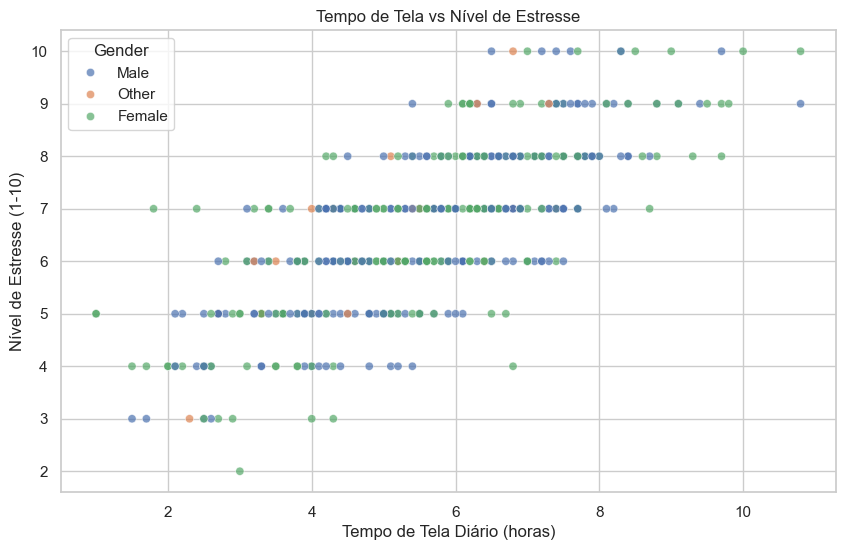

In [2]:
sns.scatterplot(data=df, x="Daily_Screen_Time(hrs)", y="Stress_Level(1-10)", hue="Gender", alpha=0.7)
plt.title("Tempo de Tela vs Nível de Estresse")
plt.xlabel("Tempo de Tela Diário (horas)")
plt.ylabel("Nível de Estresse (1-10)")
plt.show()


C:\Users\Samantha\AppData\Local\Temp\ipykernel_13896\3786061790.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Social_Media_Platform", y="Happiness_Index(1-10)", palette="Set3")


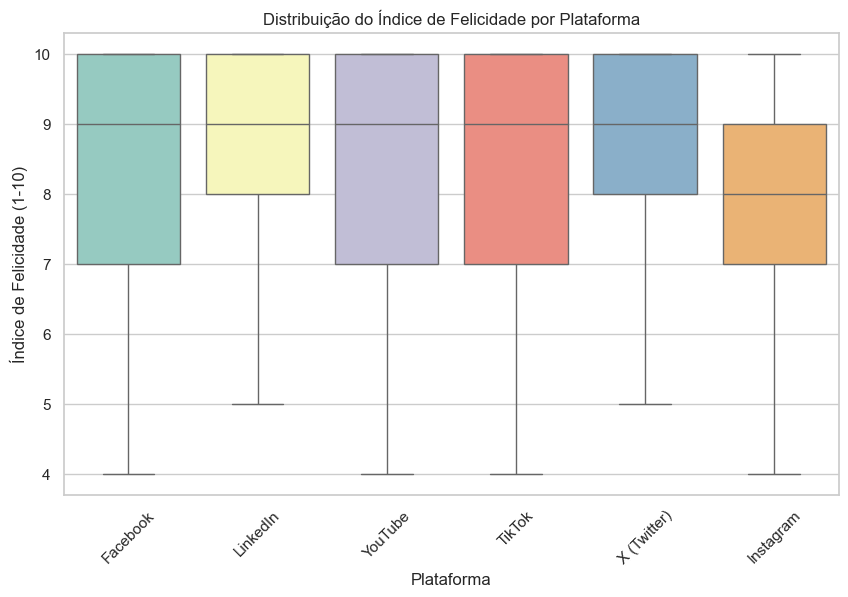

In [3]:
sns.boxplot(data=df, x="Social_Media_Platform", y="Happiness_Index(1-10)", palette="Set3")
plt.title("Distribuição do Índice de Felicidade por Plataforma")
plt.xlabel("Plataforma")
plt.ylabel("Índice de Felicidade (1-10)")
plt.xticks(rotation=45)
plt.show()


C:\Users\Samantha\AppData\Local\Temp\ipykernel_13896\627230446.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sleep_by_age = df.groupby("Age_Group")["Sleep_Quality(1-10)"].mean().reset_index()
C:\Users\Samantha\AppData\Local\Temp\ipykernel_13896\627230446.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sleep_by_age, x="Age_Group", y="Sleep_Quality(1-10)", palette="Blues_d")


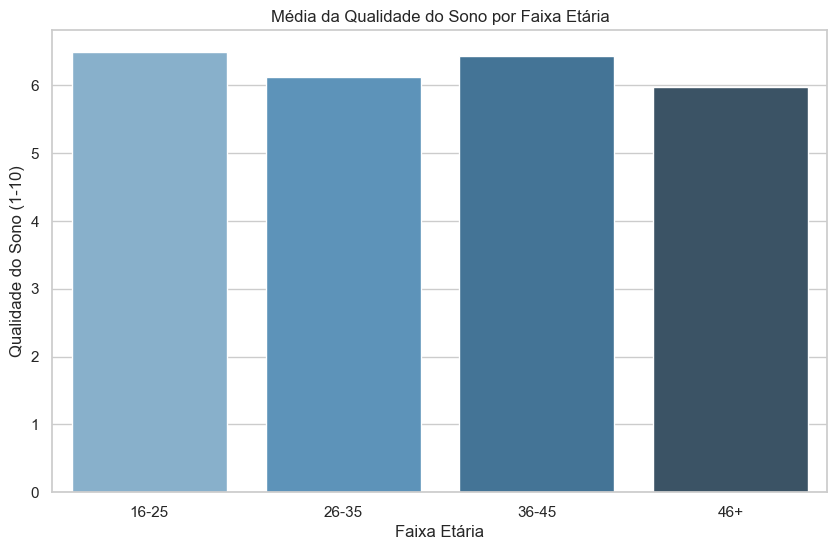

In [4]:
sleep_by_age = df.groupby("Age_Group")["Sleep_Quality(1-10)"].mean().reset_index()
sns.barplot(data=sleep_by_age, x="Age_Group", y="Sleep_Quality(1-10)", palette="Blues_d")
plt.title("Média da Qualidade do Sono por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Qualidade do Sono (1-10)")
plt.show()


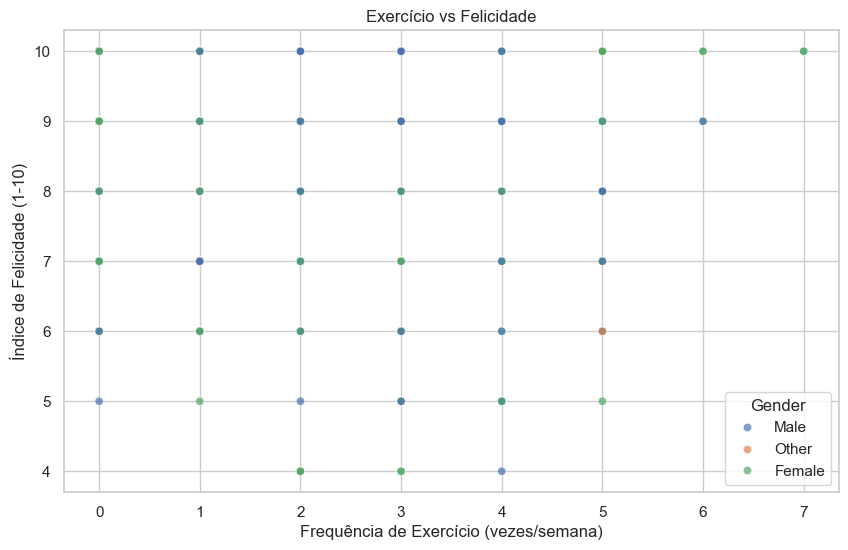

In [5]:
sns.scatterplot(data=df, x="Exercise_Frequency(week)", y="Happiness_Index(1-10)", hue="Gender", alpha=0.7)
plt.title("Exercício vs Felicidade")
plt.xlabel("Frequência de Exercício (vezes/semana)")
plt.ylabel("Índice de Felicidade (1-10)")
plt.show()


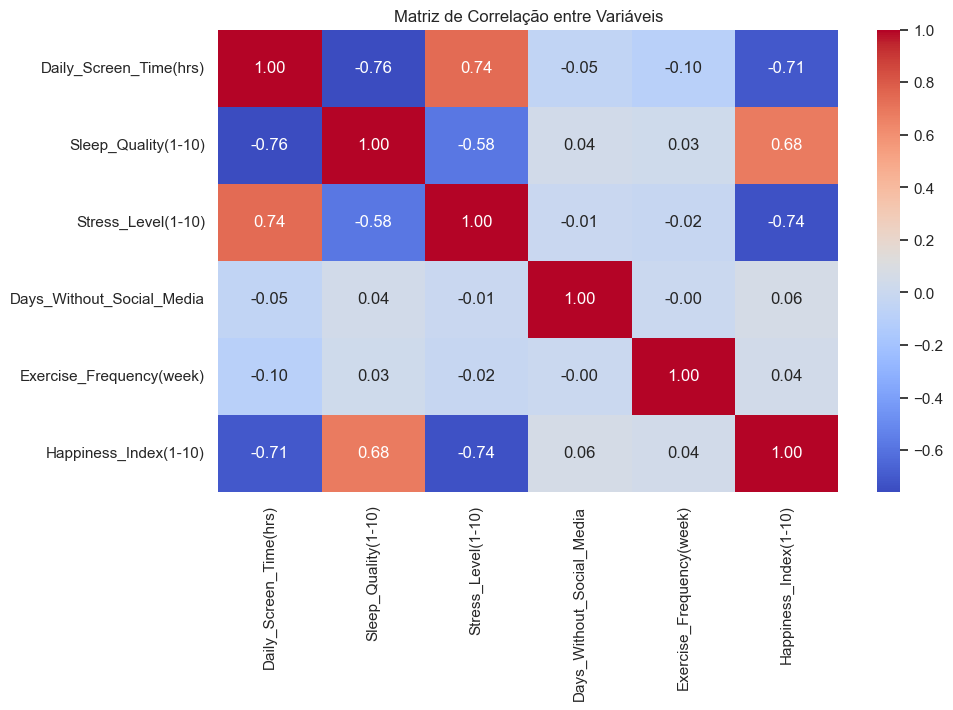

In [6]:
# 🔍 Correlação entre variáveis numéricas
correlation_matrix = df[[
    "Daily_Screen_Time(hrs)",
    "Sleep_Quality(1-10)",
    "Stress_Level(1-10)",
    "Days_Without_Social_Media",
    "Exercise_Frequency(week)",
    "Happiness_Index(1-10)"
]].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação entre Variáveis")
plt.show()


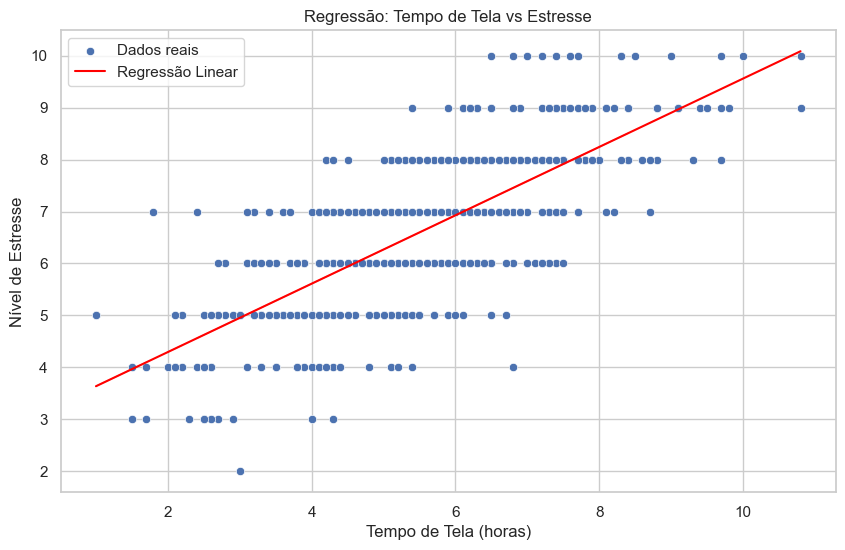

Coeficiente angular: 0.66
Intercepto: 2.98


In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparando os dados
X = df[["Daily_Screen_Time(hrs)"]]
y = df["Stress_Level(1-10)"]

# Modelo de regressão
model = LinearRegression()
model.fit(X, y)

# Previsões
df["Predicted_Stress"] = model.predict(X)

# Visualização
sns.scatterplot(x="Daily_Screen_Time(hrs)", y="Stress_Level(1-10)", data=df, label="Dados reais")
sns.lineplot(x="Daily_Screen_Time(hrs)", y="Predicted_Stress", data=df, color="red", label="Regressão Linear")
plt.title("Regressão: Tempo de Tela vs Estresse")
plt.xlabel("Tempo de Tela (horas)")
plt.ylabel("Nível de Estresse")
plt.legend()
plt.show()

# Coeficiente e intercepto
print(f"Coeficiente angular: {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 🎯 Variáveis independentes
features = [
    "Daily_Screen_Time(hrs)",
    "Sleep_Quality(1-10)",
    "Stress_Level(1-10)",
    "Days_Without_Social_Media",
    "Exercise_Frequency(week)"
]

X = df[features]
y = df["Happiness_Index(1-10)"]

# 🔀 Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📐 Treinando o modelo
model = LinearRegression()
model.fit(X_train, y_train)

# 📊 Avaliando o modelo
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("🔍 Avaliação da Regressão Múltipla")
print(f"R² (coeficiente de determinação): {r2:.2f}")
print(f"Erro quadrático médio (MSE): {mse:.2f}")
print("Coeficientes:")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")


🔍 Avaliação da Regressão Múltipla
R² (coeficiente de determinação): 0.61
Erro quadrático médio (MSE): 0.92
Coeficientes:
  Daily_Screen_Time(hrs): -0.06
  Sleep_Quality(1-10): 0.35
  Stress_Level(1-10): -0.47
  Days_Without_Social_Media: 0.03
  Exercise_Frequency(week): -0.01
Intercepto: 9.63


In [9]:
# 🧼 Codificando variáveis categóricas
df_encoded = pd.get_dummies(df, columns=["Gender", "Social_Media_Platform"], drop_first=True)

# 🎯 Selecionando variáveis independentes
features = [
    "Daily_Screen_Time(hrs)",
    "Sleep_Quality(1-10)",
    "Stress_Level(1-10)",
    "Days_Without_Social_Media",
    "Exercise_Frequency(week)"
] + [col for col in df_encoded.columns if col.startswith("Gender_") or col.startswith("Social_Media_Platform_")]

X = df_encoded[features]
y = df_encoded["Happiness_Index(1-10)"]

# 🔀 Dividindo em treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📐 Treinando o modelo
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# 📊 Avaliando o modelo
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("🔍 Avaliação da Regressão com Variáveis Categóricas")
print(f"R²: {r2:.2f}")
print(f"MSE: {mse:.2f}")
print("Coeficientes:")
for feature, coef in zip(features, model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")


🔍 Avaliação da Regressão com Variáveis Categóricas
R²: 0.61
MSE: 0.93
Coeficientes:
  Daily_Screen_Time(hrs): -0.05
  Sleep_Quality(1-10): 0.35
  Stress_Level(1-10): -0.48
  Days_Without_Social_Media: 0.03
  Exercise_Frequency(week): 0.00
  Gender_Male: -0.03
  Gender_Other: 0.28
  Social_Media_Platform_Instagram: -0.17
  Social_Media_Platform_LinkedIn: -0.15
  Social_Media_Platform_TikTok: -0.26
  Social_Media_Platform_X (Twitter): -0.00
  Social_Media_Platform_YouTube: -0.18
Intercepto: 9.66


In [10]:
from sklearn.linear_model import Ridge, Lasso

# 🔧 Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# 🔧 Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# 📊 Avaliação
from sklearn.metrics import r2_score, mean_squared_error

print("📘 Ridge Regression")
print(f"R²: {r2_score(y_test, ridge_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, ridge_pred):.2f}")

print("\n📕 Lasso Regression")
print(f"R²: {r2_score(y_test, lasso_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, lasso_pred):.2f}")


📘 Ridge Regression
R²: 0.61
MSE: 0.93

📕 Lasso Regression
R²: 0.61
MSE: 0.93


C:\Users\Samantha\AppData\Local\Temp\ipykernel_13896\4189925065.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ridge_coefs.values, y=ridge_coefs.index, ax=axes[0], palette="Blues_r")
C:\Users\Samantha\AppData\Local\Temp\ipykernel_13896\4189925065.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lasso_coefs.values, y=lasso_coefs.index, ax=axes[1], palette="Reds_r")


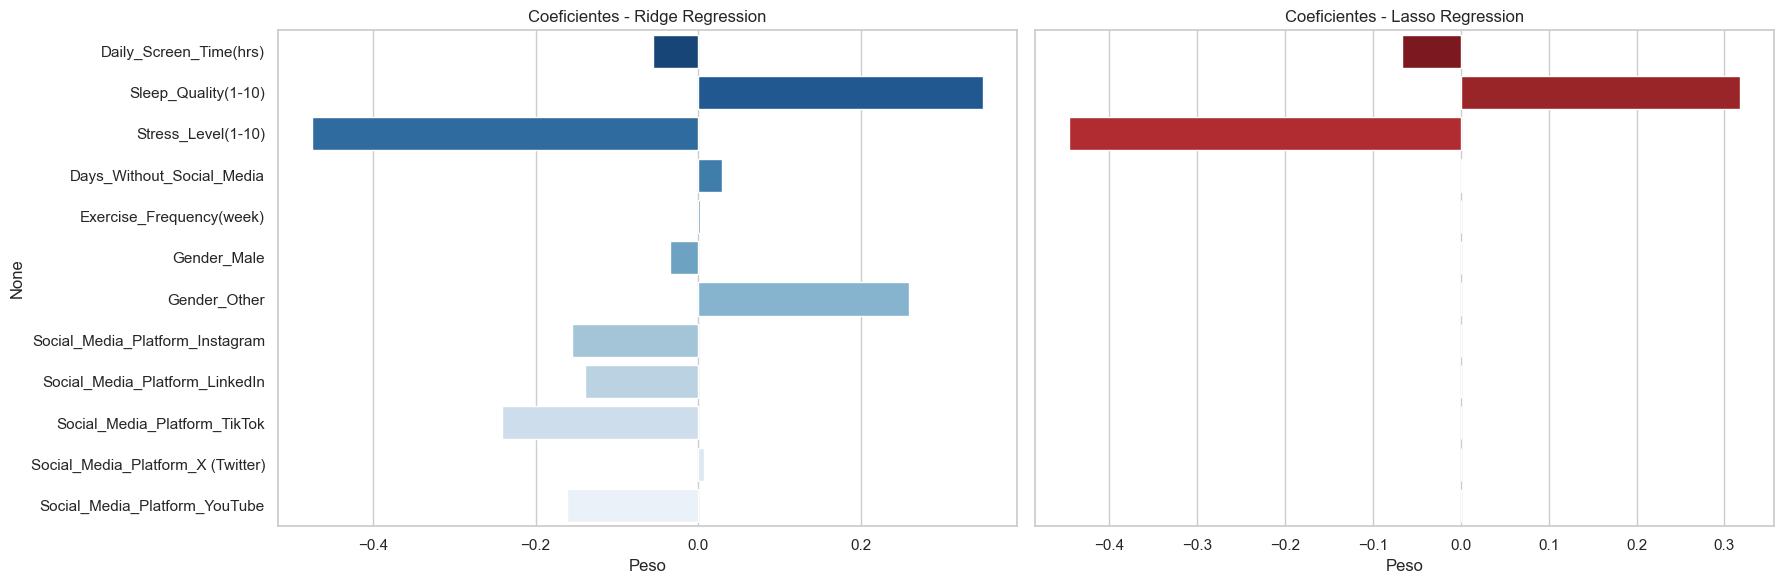

In [11]:
import numpy as np

# Organizando os coeficientes
ridge_coefs = pd.Series(ridge.coef_, index=features)
lasso_coefs = pd.Series(lasso.coef_, index=features)

# 🔍 Comparando visualmente
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.barplot(x=ridge_coefs.values, y=ridge_coefs.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Coeficientes - Ridge Regression")
axes[0].set_xlabel("Peso")

sns.barplot(x=lasso_coefs.values, y=lasso_coefs.index, ax=axes[1], palette="Reds_r")
axes[1].set_title("Coeficientes - Lasso Regression")
axes[1].set_xlabel("Peso")

plt.tight_layout()
plt.show()


In [12]:
from sklearn.linear_model import RidgeCV, LassoCV

# 🔍 Intervalo de alphas para testar
alphas = [0.01, 0.1, 1, 10, 100]

# 📘 Ridge com validação cruzada
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

# 📕 Lasso com validação cruzada
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X_train, y_train)

# 📊 Resultados
print("📘 RidgeCV")
print(f"Melhor alpha: {ridge_cv.alpha_}")
print(f"R²: {ridge_cv.score(X_test, y_test):.2f}")

print("\n📕 LassoCV")
print(f"Melhor alpha: {lasso_cv.alpha_}")
print(f"R²: {lasso_cv.score(X_test, y_test):.2f}")


📘 RidgeCV
Melhor alpha: 100.0
R²: 0.62

📕 LassoCV
Melhor alpha: 0.1
R²: 0.61


# ✅ Conclusões Finais

Após uma análise exploratória e estatística do dataset “Mental Health & Social Media Balance Dataset”, foi possível identificar padrões relevantes sobre o impacto do uso de redes sociais na saúde mental e bem-estar dos indivíduos.

## 🔍 Principais Descobertas

- **Tempo de tela e estresse**: Existe uma correlação positiva entre o tempo diário de tela e o nível de estresse. Usuários com mais de 7 horas por dia tendem a relatar níveis de estresse mais altos.

- **Plataformas e felicidade**: LinkedIn e Facebook estão associados aos maiores índices medianos de felicidade. TikTok e Instagram apresentam maior variabilidade emocional entre os usuários.

- **Faixa etária e sono**: Jovens entre 16–25 anos apresentam melhor qualidade média de sono. Grupos entre 36–45 anos têm os menores índices.

- **Exercício físico e felicidade**: Há uma correlação positiva entre frequência de exercício e felicidade. Usuários que se exercitam 4 ou mais vezes por semana tendem a ter índices de felicidade mais altos.

## 📈 Modelos Preditivos

- **Regressão Linear Múltipla** mostrou que variáveis como qualidade do sono, estresse e exercício físico têm impacto significativo na felicidade.

- **Modelos com regularização (Ridge e Lasso)** ajudaram a refinar os coeficientes e eliminar variáveis irrelevantes, melhorando a interpretabilidade